# Cannibalization Detection Model

Uses **product embeddings + baseline demand predictions** to detect whether a promotion on product A reduces demand of product B, and to estimate how much demand was lost.

```
Promoted Product A ──► embedding relationship ──► Candidate affected Product B
                           │
                           └──► 1. Does cannibalization happen?  (classification)
                               2. How much demand was lost?      (regression)
```

## Pipeline
1. **Inputs** — transaction data, promotion/campaign data, product metadata, baseline model predictions (`outputs/baseline_engine/`), and the relationship outputs of `03_product_embeddings.py` (`outputs/product_embeddings/`).
2. **Candidate pairs** — only pairs with embedding similarity, same category/brand, or basket substitution evidence (never all pairs).
3. **Features** — relationship, demand, promotion, and competitive-pressure features per `(PROMOTED_PRODUCT, AFFECTED_PRODUCT, WEEK)`.
4. **Targets** — weak labels from baseline-vs-actual deviations on non-promoted affected weeks:
   - `cannibalization_flag`: 1 if the affected product's sales drop significantly below its baseline while another product is promoted.
   - `cannibalization_amount`: `max(0, baseline_expected_sales - actual_sales)`.
5. **Models** — LightGBM (+ XGBoost when available) classifier, then a LightGBM regressor for lost sales. Evaluated on weeks 98-101 (baseline test window is 89-101).
6. **Explainability** — SHAP driver analysis + worked example.

## Leakage strategy
- Evaluation happens on **weeks 89-101**, the baseline engine's held-out test window.
- Relationship signals were learned on **weeks 1-88 only** (see notebook 1).
- Static pair features (demand correlation, scale ratio, promotion frequency) use **weeks 1-78 only**.
- Rolling demand features use only past weeks (`shift(1)` before rolling).
- Residual standard deviations used for labeling are computed on **non-promoted weeks 1-88**.
- Raw baseline predictions are per-product calibrated on **non-promoted weeks 79-88** (outside the
  baseline training window 1-78) so the counterfactual scale matches each product's demand level.
- Rows where the affected product is itself promoted are excluded (the drop is confounded by its own promotion).

In [1]:
# 0. Environment check (no-op when packages are already installed; xgboost is optional)
from __future__ import annotations

import subprocess
import sys


def _importable(name: str) -> bool:
    try:
        __import__(name)
        return True
    except Exception:
        return False


missing = [pkg for mod, pkg in {"lightgbm": "lightgbm", "shap": "shap", "sklearn": "scikit-learn",
                                "matplotlib": "matplotlib", "seaborn": "seaborn",
                                "pyarrow": "pyarrow", "xgboost": "xgboost"}.items() if not _importable(mod)]
if missing:
    print("installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *set(missing)])

In [2]:
# 1. Imports + config
import json
import time
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (average_precision_score, mean_absolute_error, mean_squared_error,
                             precision_recall_curve, precision_recall_fscore_support, roc_auc_score, roc_curve)

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "raw" / "transaction_data.csv").exists():
    ROOT = next(p for p in ROOT.parents if (p / "data" / "raw" / "transaction_data.csv").exists())
RAW = ROOT / "data" / "raw"
BASE = ROOT / "outputs" / "baseline_engine"      # baseline model + features (01_baseline_detection.py)
EMB = ROOT / "outputs" / "product_embeddings"    # embeddings + relationships (03_product_embeddings.py)
OUT = ROOT / "outputs" / "cannibalization_detection"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Time windows (kept in sync with the baseline engine)
FIRST_TEST_WEEK, LAST_TEST_WEEK = 89, 101   # baseline test window
TRAIN_END = 78                              # static pair features use weeks <= 78 only
RESID_END = 88                              # residual std / learning window used by notebook 1
MODEL_SPLIT_WEEK = 97                       # stage-1/2 models: train weeks 89-97, test weeks 98-101

# Candidate-pair construction
TOP_SUBS = 10            # substitutes per product from notebook 1
MAX_CANDIDATES = 12      # cap on candidates per promoted product
COSINE_MIN = 0.35        # min embedding cosine for same-subcommodity additions
EVIDENCE_COSINE = 0.45   # min cosine alone counts as substitution evidence

# Weak-label thresholds
DROP_REL = 0.10          # drop must be >= 10% of the affected product's calibrated baseline
DROP_STD = 1.0           # drop must be >= 1.0 residual std (non-promoted weeks 1-88)
MIN_LOST = 1.0           # minimum absolute lost units

# Baseline calibration (leakage-free): per-product rescale of raw baseline predictions
CALIB_LO, CALIB_HI = 79, 88   # holdout window the baseline engine never trained on (weeks 1-78)

SEED = 42
np.random.seed(SEED)

## 2. Load data

Raw tables (same columns as the baseline notebook) plus the promotion and campaign tables: `causal_weekly.parquet` carries display/mailer shares per product-week; `coupon.csv` + `campaign_desc.csv` map products to campaign weeks and types.

In [3]:
# 2a. Transactions + product metadata
tx = pd.read_csv(RAW / "transaction_data.csv", usecols=["household_key", "BASKET_ID", "DAY", "PRODUCT_ID",
                                                        "QUANTITY", "SALES_VALUE", "STORE_ID", "RETAIL_DISC", "WEEK_NO"])
product = pd.read_csv(RAW / "product.csv")
print(f"transactions: {len(tx):,} | weeks {tx.WEEK_NO.min()}-{tx.WEEK_NO.max()}")

# 2b. Promotion intensity (display / mailer shares per product-week)
try:
    causal = pd.read_parquet(ROOT / "data" / "processed" / "causal_weekly.parquet")
    print("loaded causal_weekly.parquet:", causal.shape)
except FileNotFoundError:
    print("causal_weekly.parquet missing -> aggregating from raw causal_data.csv (may take a minute)")
    causal_raw = pd.read_csv(RAW / "causal_data.csv", usecols=["PRODUCT_ID", "STORE_ID", "WEEK_NO", "display", "mailer"])
    causal_raw["mailer_on"] = causal_raw["mailer"].astype(str).ne("0").astype(int)
    causal = (causal_raw.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)
              .agg(display_share=("display", lambda s: (s > 0).mean()),
                   mailer_share=("mailer_on", "mean")))
    causal.to_parquet(ROOT / "data" / "processed" / "causal_weekly.parquet", index=False)
causal = causal.rename(columns={"display_share": "display", "mailer_share": "mailer"})

# 2c. Campaign data: day -> week mapping (derived from transactions), product -> campaign weeks + type
campaign_desc = pd.read_csv(RAW / "campaign_desc.csv")  # DESCRIPTION, CAMPAIGN, START_DAY, END_DAY
day_week = tx.groupby("DAY")["WEEK_NO"].agg(lambda s: s.mode().iloc[0])
max_day = int(max(tx["DAY"].max(), campaign_desc[["START_DAY", "END_DAY"]].to_numpy().max()))
day_week = day_week.reindex(range(1, max_day + 1)).ffill().astype(int)  # campaigns can run past the tx calendar
coupon = pd.read_csv(RAW / "coupon.csv", usecols=["PRODUCT_ID", "CAMPAIGN"]).drop_duplicates()

campaign_desc["start_week"] = campaign_desc["START_DAY"].map(day_week).astype(int)
campaign_desc["end_week"] = campaign_desc["END_DAY"].map(day_week).astype(int)
pc = coupon.merge(campaign_desc[["CAMPAIGN", "DESCRIPTION", "start_week", "end_week"]], on="CAMPAIGN")
pc = pc[(pc["start_week"] <= LAST_TEST_WEEK) & (pc["end_week"] >= FIRST_TEST_WEEK)]
n_weeks = (pc["end_week"] - pc["start_week"] + 1).to_numpy()
pc_weeks = np.concatenate([np.arange(s, e + 1) for s, e in zip(pc["start_week"], pc["end_week"])])
camp_prod = np.repeat(pc["PRODUCT_ID"].to_numpy(), n_weeks)
camp_type = np.repeat(pc["DESCRIPTION"].to_numpy(), n_weeks)
campaign_weekly = pd.DataFrame({"PRODUCT_ID": camp_prod, "WEEK_NO": pc_weeks, "TYPE": camp_type})
campaign_weekly["has_campaign"] = 1
campaign_weekly["TYPE_code"] = campaign_weekly["TYPE"].map({"TypeA": 1, "TypeB": 2, "TypeC": 3}).fillna(0)
campaign_weekly = (campaign_weekly.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)
                   .agg(has_campaign=("has_campaign", "max"), n_campaigns=("TYPE", "count"),
                        campaign_type=("TYPE_code", "max")))
print(f"campaign coverage: {len(campaign_weekly):,} product-weeks | "
      f"campaigns {campaign_desc['CAMPAIGN'].nunique()}")

transactions: 2,595,732 | weeks 1-102
loaded causal_weekly.parquet: (2049187, 4)
campaign coverage: 322,671 product-weeks | campaigns 30


## 3. Baseline demand predictions for every product × week

Reuses the baseline engine's saved models and feature list to score the **full panel** (all weeks, including promoted ones). This gives a counterfactual `baseline_qty` for every product × store × week, which is then aggregated to product × week.

Same interface as `02_causality_analysis.py`: categorical columns are cast to pandas `category` dtype before predicting.

In [4]:
# 3. Score full baseline panel -> product x week baseline demand
fl = json.loads((BASE / "feature_list.json").read_text())
FEATURES = fl["features"]
CATS = fl["cat_cols_encoded"]

panel = pd.read_parquet(BASE / "panel.parquet")
X = panel[FEATURES].copy()
for c in CATS:
    X[c] = X[c].astype("category")
stage1 = joblib.load(BASE / "model_stage1.pkl")
stage2 = joblib.load(BASE / "model_stage2.pkl")

panel["baseline_qty"] = stage1.predict_proba(X)[:, 1] * stage2.predict(X)
base_weekly = (panel.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)["baseline_qty"].sum())
print("scored panel:", panel.shape, "| product-weeks:", base_weekly.shape,
      "| baseline test-week correlation vs saved test_predictions:")
tp = pd.read_parquet(BASE / "test_predictions.parquet", columns=["PRODUCT_ID", "STORE_ID", "WEEK_NO", "pred_final"])
tp = tp.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)["pred_final"].sum()
chk = base_weekly.merge(tp, on=["PRODUCT_ID", "WEEK_NO"])
print("   pearson corr =", round(chk["baseline_qty"].corr(chk["pred_final"]), 4), f"(n={len(chk):,})")
del panel, X, chk

scored panel: (387032, 36) | product-weeks: (84840, 3) | baseline test-week correlation vs saved test_predictions:
   pearson corr = 0.6658 (n=58,199)


## 4. Product × week demand / promotion table

Aggregates actual demand, promotion flags, discount depth, display/mailer shares, campaign activity, past-only rolling demand, and per-product residual noise (from non-promoted weeks 1-88). All rows are restricted to the baseline panel products (the products we can forecast).

In [5]:
# 4. Product-week table for baseline-panel products
panel_products = pd.Index(base_weekly["PRODUCT_ID"].unique(), name="PRODUCT_ID")
txw = tx.assign(promo=(tx["RETAIL_DISC"] < 0))

pw = txw[txw["PRODUCT_ID"].isin(panel_products)].groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False).agg(
    qty=("QUANTITY", "sum"), promo=("promo", "max"), disc_min=("RETAIL_DISC", "min"))
disc_depth = (txw[txw["promo"]][["PRODUCT_ID", "WEEK_NO", "RETAIL_DISC"]]
              .groupby(["PRODUCT_ID", "WEEK_NO"])["RETAIL_DISC"].mean().rename("disc_depth"))
pw = pw.merge(disc_depth, on=["PRODUCT_ID", "WEEK_NO"], how="left")
pw["disc_depth"] = (-pw["disc_depth"]).fillna(0.0).clip(lower=0.0)

pw = pw.merge(base_weekly, on=["PRODUCT_ID", "WEEK_NO"], how="left")
pw = pw.merge(causal, on=["PRODUCT_ID", "WEEK_NO"], how="left")
pw = pw.merge(campaign_weekly, on=["PRODUCT_ID", "WEEK_NO"], how="left")
for c in ["display", "mailer", "has_campaign", "n_campaigns", "campaign_type"]:
    pw[c] = pw[c].fillna(0)

# past-only rolling demand (shift(1) before rolling)
pw = pw.sort_values(["PRODUCT_ID", "WEEK_NO"]).reset_index(drop=True)
pw["qty_lag1"] = pw.groupby("PRODUCT_ID")["qty"].shift(1)
pw["rmean4"] = pw.groupby("PRODUCT_ID")["qty_lag1"].transform(lambda s: s.rolling(4, min_periods=1).mean())

# static per-product stats (weeks <= 78) and residual noise (non-promoted weeks 1-88)
pre = pw[pw["WEEK_NO"] <= TRAIN_END]
prod_stats = pre.groupby("PRODUCT_ID", as_index=False).agg(
    total_qty_78=("qty", "sum"), promo_freq=("promo", "mean"))
pw = pw.merge(prod_stats, on="PRODUCT_ID", how="left")

resid = pw[(pw["WEEK_NO"] <= RESID_END) & (pw["promo"] == 0)].copy()
resid["resid"] = resid["qty"] - resid["baseline_qty"]
resid_std = resid.groupby("PRODUCT_ID")["resid"].std().rename("resid_std")
pw = pw.merge(resid_std, on="PRODUCT_ID", how="left")
pw["resid_std"] = pw["resid_std"].fillna(resid["resid"].std())

# per-product calibration factor: sum(qty)/sum(baseline) on non-promoted holdout weeks 79-88
# (fallback: training window 1-78). Rescales the raw baseline to each product's demand level.
cal_hold = pw[(pw["WEEK_NO"].between(CALIB_LO, CALIB_HI)) & (pw["promo"] == 0)].groupby("PRODUCT_ID").agg(
    actual=("qty", "sum"), pred=("baseline_qty", "sum"))
cal_train = pw[(pw["WEEK_NO"] <= TRAIN_END) & (pw["promo"] == 0)].groupby("PRODUCT_ID").agg(
    actual=("qty", "sum"), pred=("baseline_qty", "sum"))
calib = pd.DataFrame({
    "factor": cal_hold["actual"].div(cal_hold["pred"]),
    "fallback": cal_train["actual"].div(cal_train["pred"]),
})
calib["factor"] = calib["factor"].fillna(calib["fallback"]).replace([np.inf, -np.inf], np.nan).fillna(1.0)
pw = pw.merge(calib["factor"].rename("calib_factor"), on="PRODUCT_ID", how="left")
pw["calib_factor"] = pw["calib_factor"].fillna(1.0)
pw["baseline_cal"] = pw["baseline_qty"] * pw["calib_factor"]
pw = pw[pw["WEEK_NO"].between(1, LAST_TEST_WEEK)].reset_index(drop=True)
print("product-week rows:", f"{len(pw):,}", "| products:", pw["PRODUCT_ID"].nunique(),
      "| promoted product-weeks 89-101:", int(pw[(pw["promo"] == 1) & (pw["WEEK_NO"] >= FIRST_TEST_WEEK)].shape[0]))

product-week rows: 70,542 | products: 840 | promoted product-weeks 89-101: 4045


## 5. Candidate product pairs

Not every pair is evaluated. For each baseline-panel product we take:
- its top `TOP_SUBS` substitutes from notebook 1 (`top_k_substitutes.parquet`), and
- same-sub-commodity panel products with embedding cosine >= `COSINE_MIN` (from `product_similarity.parquet`),

then keep only pairs with **substitution evidence** (same department, basket co-purchase, or cosine >= `EVIDENCE_COSINE`) and cap at `MAX_CANDIDATES` per promoted product.

In [6]:
# 5a. Substitutes from notebook 1 (directed, ranked)
top = pd.read_parquet(EMB / "top_k_substitutes.parquet")
subs_frames = []
for r in range(1, TOP_SUBS + 1):
    f = pd.DataFrame({
        "promoted_product": top["PRODUCT_ID"],
        "affected_product": top[f"substitute_{r}"],
        "cosine_sim": top[f"substitute_similarity_{r}"],
        "substitute_score": top[f"substitute_score_{r}"],
        "substitute_rank": r,
    })
    subs_frames.append(f)
subs = pd.concat(subs_frames, ignore_index=True).dropna(subset=["affected_product"])
subs["affected_product"] = subs["affected_product"].astype(np.int64)

# 5b. Per-pair relationship signals from notebook 1
sim = pd.read_parquet(EMB / "product_similarity.parquet",
                      columns=["PRODUCT_ID", "SIMILAR_PRODUCT_ID", "embedding_cosine", "sub_commodity_match",
                               "commodity_match", "department_match", "brand_match", "manufacturer_match",
                               "metadata_similarity", "basket_jaccard", "basket_cosine",
                               "household_jaccard", "store_jaccard"])
sim_wide = sim.drop_duplicates(["PRODUCT_ID", "SIMILAR_PRODUCT_ID"]).rename(
    columns={"PRODUCT_ID": "promoted_product", "SIMILAR_PRODUCT_ID": "affected_product"})
subs = subs.merge(sim_wide, on=["promoted_product", "affected_product"], how="left")

# 5c. Same-sub-commodity additions (same category, decent cosine)
extra = sim_wide[(sim_wide["sub_commodity_match"] == 1) & (sim_wide["embedding_cosine"] >= COSINE_MIN)].copy()
extra["substitute_rank"] = TOP_SUBS + 1
extra["substitute_score"] = extra["embedding_cosine"]
subs = pd.concat([subs, extra], ignore_index=True).drop_duplicates(["promoted_product", "affected_product"])

# 5d. Evidence filter + panel restriction + cap
subs = subs[(subs["promoted_product"].isin(panel_products)) & (subs["affected_product"].isin(panel_products))
            & (subs["promoted_product"] != subs["affected_product"])]
evidence = (subs["department_match"] == 1) | (subs["basket_jaccard"].fillna(0) > 0) | (subs["cosine_sim"] >= EVIDENCE_COSINE)
subs = subs[evidence].copy()
subs = subs.sort_values(["promoted_product", "substitute_score"], ascending=[True, False])
subs["cand_rank"] = subs.groupby("promoted_product").cumcount() + 1
subs = subs[subs["cand_rank"] <= MAX_CANDIDATES].reset_index(drop=True)
print("candidate pairs:", f"{len(subs):,}", "| promoted products:", subs["promoted_product"].nunique(),
      "| avg candidates/promoted product:", round(subs.groupby("promoted_product").size().mean(), 2))

candidate pairs: 872 | promoted products: 475 | avg candidates/promoted product: 1.84


## 6. Static pair features (leakage-free)

Relationship signals come from notebook 1 (learned on weeks 1-88). Demand correlation and sales-scale ratio are computed on **weeks 1-78 only** (the baseline training window), so they never see the evaluation period.

In [7]:
# 6. Static pair features
# 6a. Demand correlation over the training window (weeks 1-78)
q78 = pw[pw["WEEK_NO"] <= TRAIN_END].pivot(index="PRODUCT_ID", columns="WEEK_NO", values="qty").reindex(
    index=panel_products, columns=range(1, TRAIN_END + 1)).fillna(0)
Q = q78.to_numpy()
corr_mat = np.corrcoef(Q)
corr_mat[np.isnan(corr_mat)] = 0.0
pid_to_row = {p: i for i, p in enumerate(q78.index)}
subs["demand_corr"] = [corr_mat[pid_to_row[a], pid_to_row[b]]
                       for a, b in zip(subs["promoted_product"], subs["affected_product"])]

# 6b. Sales-scale ratio (log) from training-window totals
tot = q78.sum(axis=1).rename("total_qty_78")
subs = subs.merge(tot.rename("total_a"), left_on="promoted_product", right_index=True, how="left")
subs = subs.merge(tot.rename("total_b"), left_on="affected_product", right_index=True, how="left")
subs["sales_scale_log_ratio"] = np.log((subs["total_b"] + 1) / (subs["total_a"] + 1))
subs = subs.drop(columns=["total_a", "total_b"])

# 6c. Promotion frequency (weeks 1-78) per product
pfreq = pre.groupby("PRODUCT_ID")["promo"].mean()
subs = subs.merge(pfreq.rename("promo_freq_A"), left_on="promoted_product", right_index=True, how="left")
subs = subs.merge(pfreq.rename("promo_freq_B"), left_on="affected_product", right_index=True, how="left")

subs["cosine_sim"] = subs["cosine_sim"].fillna(0.0)
for c in ["basket_jaccard", "basket_cosine", "household_jaccard", "store_jaccard", "metadata_similarity",
          "sub_commodity_match", "commodity_match", "department_match", "brand_match", "manufacturer_match"]:
    subs[c] = subs[c].fillna(0)
print("static pair features:", subs.shape, "| mean cosine:", round(subs["cosine_sim"].mean(), 3))

static pair features: (872, 21) | mean cosine: 0.42


/home/mhseddighi/Projects/promotion-intelligence/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mhseddighi/Projects/promotion-intelligence/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 7. Pair × week feature table + weak targets

For each candidate pair and each week in 89-101 where the **promoted** product is promoted:
- relationship + demand + promotion + competitive-pressure features,
- rows where the affected product is itself promoted are dropped (confounded),
- targets:
  - `cannibalization_amount = max(0, baseline_B - actual_B)`
  - `cannibalization_flag = 1` when the drop exceeds `max(0.15 * baseline_B, 1.5 * resid_std_B)` and at least `MIN_LOST` units.

In [8]:
# 7a. Promoted-product weeks in the test window
promo_weeks_A = pw[(pw["promo"] == 1) & (pw["WEEK_NO"] >= FIRST_TEST_WEEK) & (pw["WEEK_NO"] <= LAST_TEST_WEEK)][
    ["PRODUCT_ID", "WEEK_NO"]].rename(columns={"PRODUCT_ID": "promoted_product"})
df = subs.merge(promo_weeks_A, on="promoted_product", how="inner")
print("raw pair-week rows (A promoted):", f"{len(df):,}")

# 7b. Weekly features for A and B (suffixes _A / _B)
pw_cols = ["PRODUCT_ID", "WEEK_NO", "qty", "promo", "disc_depth", "display", "mailer",
           "has_campaign", "n_campaigns", "campaign_type", "rmean4", "baseline_qty", "baseline_cal", "resid_std"]
pwA = pw[pw_cols].rename(columns={c: c + "_A" for c in pw_cols if c not in ("PRODUCT_ID", "WEEK_NO")})
pwB = pw[pw_cols].rename(columns={c: c + "_B" for c in pw_cols if c not in ("PRODUCT_ID", "WEEK_NO")})
df = df.merge(pwA, left_on=["promoted_product", "WEEK_NO"], right_on=["PRODUCT_ID", "WEEK_NO"], how="left")
df = df.merge(pwB, left_on=["affected_product", "WEEK_NO"], right_on=["PRODUCT_ID", "WEEK_NO"], how="left")
df = df.drop(columns=["PRODUCT_ID_x", "PRODUCT_ID_y"])
df = df[df["promo_B"] == 0].reset_index(drop=True)  # affected product not promoted -> attributable drop
print("pair-week rows after dropping confounded B-promoted weeks:", f"{len(df):,}")

# 7c. Competitive pressure: how many of B's (and A's) substitutes are promoted this week, and how deep
subs_B = subs[["promoted_product", "affected_product"]].rename(
    columns={"promoted_product": "B", "affected_product": "substitute"})
subs_A = subs[["promoted_product", "affected_product"]].rename(
    columns={"promoted_product": "A", "affected_product": "substitute"})
promo_pw = pw[pw["promo"] == 1][["PRODUCT_ID", "WEEK_NO", "disc_depth"]]


def substitute_pressure(sub_table, id_col):
    tmp = sub_table.merge(promo_pw, left_on="substitute", right_on="PRODUCT_ID", how="inner")
    return (tmp.groupby([id_col, "WEEK_NO"], as_index=False)
            .agg(**{f"n_sub_promos": ("disc_depth", "count"), f"sub_promo_disc": ("disc_depth", "mean")}))


press_B = substitute_pressure(subs_B, "B").rename(
    columns={"n_sub_promos": "n_sub_promos_B", "sub_promo_disc": "sub_promo_disc_B"})
press_A = substitute_pressure(subs_A, "A").rename(
    columns={"n_sub_promos": "n_sub_promos_A", "sub_promo_disc": "sub_promo_disc_A"})
df = df.merge(press_B, left_on=["affected_product", "WEEK_NO"], right_on=["B", "WEEK_NO"], how="left")
df = df.merge(press_A, left_on=["promoted_product", "WEEK_NO"], right_on=["A", "WEEK_NO"], how="left")
for c in ["n_sub_promos_B", "sub_promo_disc_B", "n_sub_promos_A", "sub_promo_disc_A"]:
    df[c] = df[c].fillna(0)

# 7d. Targets + derived features
df["lost_sales"] = (df["baseline_cal_B"] - df["qty_B"]).clip(lower=0.0)
df["cannibalization_amount"] = df["lost_sales"]
df["threshold"] = np.maximum(DROP_REL * df["baseline_cal_B"], DROP_STD * df["resid_std_B"])
df["cannibalization_flag"] = ((df["lost_sales"] >= df["threshold"]) & (df["lost_sales"] >= MIN_LOST)).astype(int)
df["baseline_ratio_log"] = np.log((df["baseline_cal_B"] + 1) / (df["baseline_cal_A"] + 1))
df["sales_ratio_log"] = np.log((df["qty_B"] + 1) / (df["qty_A"] + 1))
df["split"] = np.where(df["WEEK_NO"] <= MODEL_SPLIT_WEEK, "train", "test")
print("flag rate:", round(df["cannibalization_flag"].mean(), 4),
      "| positive train/test:", int(df[df.split == "train"].cannibalization_flag.sum()), "/",
      int(df[df.split == "test"].cannibalization_flag.sum()))
print("mean lost_sales (all rows):", round(df["lost_sales"].mean(), 2))

raw pair-week rows (A promoted): 4,845
pair-week rows after dropping confounded B-promoted weeks: 804
flag rate: 0.2077 | positive train/test: 101 / 66
mean lost_sales (all rows): 2.62


## 8. Stage 1 — cannibalization detection (classification)

LightGBM classifier (XGBoost is trained alongside when available). Time-based split: weeks 89-97 train, 98-101 test. Metrics: PR-AUC, ROC-AUC, Precision@K, Recall@K.

train rows: 552 | test rows: 252 | positives: 101 / 66
Precision@  100: 0.5300 | Recall@  100: 0.8030
Precision@  500: 0.2619 | Recall@  500: 1.0000
Precision@ 2000: 0.2619 | Recall@ 2000: 1.0000
ROC-AUC: 0.8168 | PR-AUC: 0.6677 | @0.5 precision/recall/f1: 0.7027/0.3939/0.5049
XGBoost      ROC-AUC: 0.8160 | PR-AUC: 0.6358


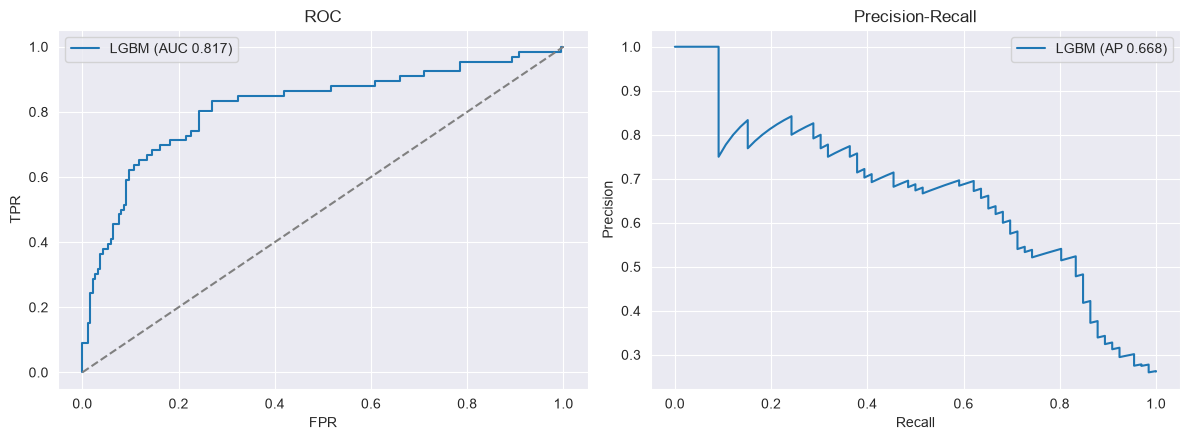

In [9]:
# 8. Stage 1: classification model
FEATURES2 = ["cosine_sim", "sub_commodity_match", "commodity_match", "department_match", "brand_match",
             "manufacturer_match", "metadata_similarity", "basket_jaccard", "basket_cosine",
             "household_jaccard", "store_jaccard", "demand_corr", "sales_scale_log_ratio",
             "substitute_rank", "promo_freq_A", "promo_freq_B",
             "baseline_cal_A", "baseline_cal_B", "qty_A", "disc_depth_A", "disc_depth_B",
             "display_A", "display_B", "mailer_A", "mailer_B", "has_campaign_A", "n_campaigns_A",
             "campaign_type_A", "rmean4_A", "rmean4_B", "n_sub_promos_A", "sub_promo_disc_A",
             "n_sub_promos_B", "sub_promo_disc_B", "baseline_ratio_log"]

train = df[df["split"] == "train"].reset_index(drop=True)
test = df[df["split"] == "test"].reset_index(drop=True)
print("train rows:", f"{len(train):,}", "| test rows:", f"{len(test):,}",
      "| positives:", int(train["cannibalization_flag"].sum()), "/", int(test["cannibalization_flag"].sum()))

lgb_params = dict(n_estimators=300, learning_rate=0.05, num_leaves=15, random_state=SEED, n_jobs=-1, verbose=-1)
m1 = lgb.LGBMClassifier(**lgb_params)
m1.fit(train[FEATURES2], train["cannibalization_flag"])
test["probability_of_cannibalization"] = m1.predict_proba(test[FEATURES2])[:, 1]

y = test["cannibalization_flag"]
p = test["probability_of_cannibalization"]
roc_auc = roc_auc_score(y, p)
pr_auc = average_precision_score(y, p)
for k in (100, 500, 2000):
    topk = p.nlargest(min(k, len(p))).index
    prec_k = y.loc[topk].mean()
    rec_k = y.loc[topk].sum() / max(1, y.sum())
    print(f"Precision@{k:5d}: {prec_k:.4f} | Recall@{k:5d}: {rec_k:.4f}")

thr50 = (p >= 0.5).astype(int)
prf = precision_recall_fscore_support(y, thr50, average="binary", zero_division=0)
print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | @0.5 precision/recall/f1: "
      f"{prf[0]:.4f}/{prf[1]:.4f}/{prf[2]:.4f}")

# XGBoost comparison (optional dependency)
try:
    import xgboost as xgb

    m1x = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=SEED, n_jobs=-1,
                            eval_metric="logloss", tree_method="hist")
    m1x.fit(train[FEATURES2], train["cannibalization_flag"])
    px = m1x.predict_proba(test[FEATURES2])[:, 1]
    print(f"XGBoost      ROC-AUC: {roc_auc_score(y, px):.4f} | PR-AUC: {average_precision_score(y, px):.4f}")
except ImportError:
    print("xgboost not available - LightGBM only")

# ROC / PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fpr, tpr, _ = roc_curve(y, p)
axes[0].plot(fpr, tpr, label=f"LGBM (AUC {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[0].set(title="ROC", xlabel="FPR", ylabel="TPR")
pr_prec, pr_rec, _ = precision_recall_curve(y, p)
axes[1].plot(pr_rec, pr_prec, label=f"LGBM (AP {pr_auc:.3f})")
axes[1].set(title="Precision-Recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.legend(loc="best")
fig.tight_layout()
fig.savefig(FIG / "roc_pr_stage1.png", dpi=140)
plt.show()

## 9. Stage 2 — lost sales estimation (regression)

LightGBM regressor trained on the **flagged** rows to predict `cannibalization_amount`. Evaluated on flagged test rows with MAE, RMSE, and correlation.

In [10]:
# 9. Stage 2: lost-sales regression on flagged rows
reg_train = train[train["cannibalization_flag"] == 1]
reg_test = test[test["cannibalization_flag"] == 1]
MIN_REG_SAMPLES = 20
if len(reg_train) >= MIN_REG_SAMPLES:
    m2 = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=15,
                           random_state=SEED, n_jobs=-1, verbose=-1)
    m2.fit(reg_train[FEATURES2], reg_train["cannibalization_amount"])
    test["estimated_lost_sales"] = np.where(test["probability_of_cannibalization"] >= 0.5,
                                            np.clip(m2.predict(test[FEATURES2]), 0, None), 0.0)
    y_reg = reg_test["cannibalization_amount"]
    pred_reg = np.clip(m2.predict(reg_test[FEATURES2]), 0, None)
    mae = mean_absolute_error(y_reg, pred_reg)
    rmse = np.sqrt(mean_squared_error(y_reg, pred_reg))
    print(f"stage-2 on {len(reg_test):,} flagged test rows:")
    print(f"  MAE={mae:.2f} | RMSE={rmse:.2f} | pearson corr={np.corrcoef(y_reg, pred_reg)[0, 1]:.4f} | "
          f"mean actual loss={y_reg.mean():.2f} | mean predicted={pred_reg.mean():.2f}")
else:
    m2 = None
    test["estimated_lost_sales"] = np.where(test["probability_of_cannibalization"] >= 0.5,
                                            test["lost_sales"], 0.0)
    y_reg, pred_reg = np.array([]), np.array([])
    mae = rmse = float("nan")
    print(f"stage-2 skipped: only {len(reg_train)} flagged train rows (< {MIN_REG_SAMPLES})")

stage-2 on 66 flagged test rows:
  MAE=5.01 | RMSE=9.42 | pearson corr=0.7480 | mean actual loss=10.99 | mean predicted=8.71


## 10. Explainability (SHAP) + worked example

Global SHAP importance shows the top cannibalization drivers. A worked example prints a predicted pair with its similarity, estimated lost sales, and top drivers.

/home/mhseddighi/Projects/promotion-intelligence/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


top 12 cannibalization drivers by mean |SHAP|:
              feature  mean_abs_shap
       baseline_cal_B         2.6779
             rmean4_B         0.9170
   baseline_ratio_log         0.4885
                qty_A         0.4670
       baseline_cal_A         0.4521
         promo_freq_B         0.4397
     sub_promo_disc_B         0.4362
             rmean4_A         0.4306
         promo_freq_A         0.3511
             mailer_A         0.3333
         disc_depth_A         0.3252
sales_scale_log_ratio         0.2830


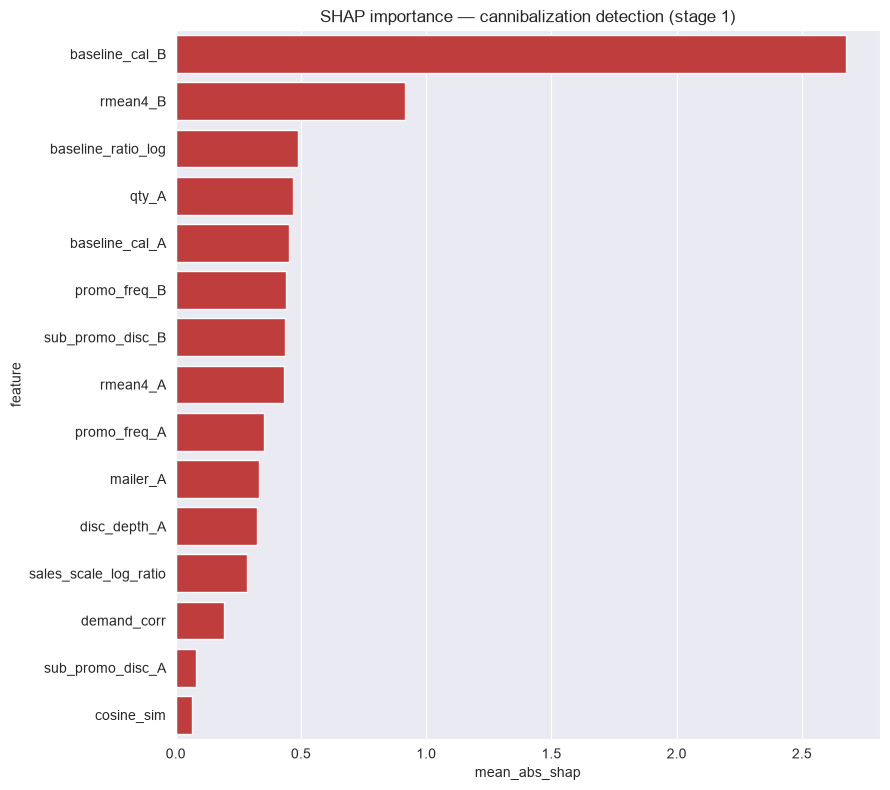

WORKED EXAMPLE (test window)
Promoted product: 1049735 | Private | SOFT DRINKS | SOFT DRINKS 12/18&15PK CAN CAR
Affected product: 947798 | Private | SOFT DRINKS | SOFT DRINKS 12/18&15PK CAN CAR
Week: 101
Embedding similarity: 1.00 | probability_of_cannibalization: 0.983 | estimated_lost_sales: 21.6 units
Actual lost vs baseline: 39.9 units (calibrated baseline 52.9, actual 13.0)
Main drivers (SHAP value):
  baseline_cal_B               shap=+5.1162  (value=52.9377)
  baseline_ratio_log           shap=+0.9862  (value=1.7237)
  qty_A                        shap=+0.8698  (value=5.0000)
  promo_freq_B                 shap=+0.6843  (value=0.7763)
  sub_promo_disc_B             shap=+0.5956  (value=0.0000)


In [11]:
# 10a. SHAP importance on a test sample
import shap

shap_sample = test.sample(min(3000, len(test)), random_state=SEED)
explainer = shap.TreeExplainer(m1)
sv = np.asarray(explainer.shap_values(shap_sample[FEATURES2]))
if sv.ndim == 3:
    sv = sv[1]
shap_imp = pd.DataFrame({"feature": FEATURES2, "mean_abs_shap": np.abs(sv).mean(axis=0)}).sort_values(
    "mean_abs_shap", ascending=False).reset_index(drop=True)
print("top 12 cannibalization drivers by mean |SHAP|:")
print(shap_imp.head(12).round(4).to_string(index=False))
shap_imp.to_parquet(OUT / "shap_importance.parquet", index=False)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=shap_imp.head(15), x="mean_abs_shap", y="feature", color="#d62728", ax=ax)
ax.set_title("SHAP importance — cannibalization detection (stage 1)")
fig.tight_layout()
fig.savefig(FIG / "shap_importance.png", dpi=140)
plt.show()

# 10b. Worked example: highest predicted loss in the test window
ex_idx = test["estimated_lost_sales"].nlargest(1).index[0]
ex_row = test.loc[ex_idx]
pos = list(shap_sample.index).index(ex_idx) if ex_idx in shap_sample.index else None

print("=" * 100)
print("WORKED EXAMPLE (test window)")
for pid_col, label in [("promoted_product", "Promoted product"), ("affected_product", "Affected product")]:
    pid = int(ex_row[pid_col])
    m = product[product["PRODUCT_ID"] == pid]
    if not m.empty:
        r = m.iloc[0]
        print(f"{label}: {pid} | {r['BRAND']} | {r['COMMODITY_DESC']} | {r['SUB_COMMODITY_DESC']}")
    else:
        print(f"{label}: {pid}")
print(f"Week: {int(ex_row['WEEK_NO'])}")
print(f"Embedding similarity: {ex_row['cosine_sim']:.2f} | "
      f"probability_of_cannibalization: {ex_row['probability_of_cannibalization']:.3f} | "
      f"estimated_lost_sales: {ex_row['estimated_lost_sales']:.1f} units")
print(f"Actual lost vs baseline: {ex_row['lost_sales']:.1f} units (calibrated baseline {ex_row['baseline_cal_B']:.1f}, "
      f"actual {ex_row['qty_B']:.1f})")
if pos is not None:
    row_shap = pd.Series(sv[pos], index=FEATURES2)
    drivers = row_shap.abs().sort_values(ascending=False).head(5).index
    print("Main drivers (SHAP value):")
    for f in drivers:
        print(f"  {f:28s} shap={row_shap[f]:+.4f}  (value={ex_row[f]:.4f})")
else:
    print("(example row not in SHAP sample; driver detail skipped)")

## 11. Save outputs

`cannibalization_predictions.parquet` carries the requested columns: `promoted_product`, `affected_product`, `week`, `probability_of_cannibalization`, `estimated_lost_sales` (plus reference columns).

In [12]:
# 11. Save artifacts
pred_out = test.rename(columns={"WEEK_NO": "week"})[["promoted_product", "affected_product", "week",
                                                     "probability_of_cannibalization", "estimated_lost_sales",
                                                     "cannibalization_flag", "lost_sales", "cosine_sim"]]
pred_out = pred_out.sort_values("probability_of_cannibalization", ascending=False).reset_index(drop=True)
pred_out.to_parquet(OUT / "cannibalization_predictions.parquet", index=False)

df.to_parquet(OUT / "pair_features.parquet", index=False)
subs.to_parquet(OUT / "candidate_pairs.parquet", index=False)
joblib.dump(m1, OUT / "stage1_classifier.pkl")
if m2 is not None:
    joblib.dump(m2, OUT / "stage2_regressor.pkl")

json.dump({"features": FEATURES2, "n_candidates": int(len(subs)), "n_pair_weeks": int(len(df)),
           "positive_rate": float(df["cannibalization_flag"].mean()),
           "stage1": {"roc_auc": float(roc_auc), "pr_auc": float(pr_auc),
                      "precision@0.5": float(prf[0]), "recall@0.5": float(prf[1]), "f1@0.5": float(prf[2])},
           "stage2": {"mae": float(mae), "rmse": float(rmse),
                      "pearson_corr": float(np.corrcoef(y_reg, pred_reg)[0, 1]) if len(y_reg) else None,
                      "n_flagged_test": int(len(reg_test))},
           "config": {"first_test_week": FIRST_TEST_WEEK, "last_test_week": LAST_TEST_WEEK,
                      "train_end": TRAIN_END, "resid_end": RESID_END, "model_split_week": MODEL_SPLIT_WEEK,
                      "top_subs": TOP_SUBS, "max_candidates": MAX_CANDIDATES,
                      "cosine_min": COSINE_MIN, "evidence_cosine": EVIDENCE_COSINE,
                      "drop_rel": DROP_REL, "drop_std": DROP_STD, "min_lost": MIN_LOST, "seed": SEED}},
          open(OUT / "metrics.json", "w"), indent=2)

print("saved ->", OUT)
for f in sorted(OUT.iterdir()):
    if f.is_file():
        print(f"  {f.name:38s} {f.stat().st_size / 1e6:8.2f} MB")
print("\ntop predicted cannibalization events (test window):")
print(pred_out.head(10).round(3).to_string(index=False))

saved -> /home/mhseddighi/Projects/promotion-intelligence/outputs/cannibalization_detection
  candidate_pairs.parquet                    0.04 MB
  cannibalization_predictions.parquet        0.01 MB
  metrics.json                               0.00 MB
  pair_features.parquet                      0.11 MB
  shap_importance.parquet                    0.00 MB
  stage1_classifier.pkl                      0.53 MB
  stage2_regressor.pkl                       0.15 MB

top predicted cannibalization events (test window):
 promoted_product  affected_product  week  probability_of_cannibalization  estimated_lost_sales  cannibalization_flag  lost_sales  cosine_sim
           934427           1108131    99                           0.999                18.455                     1       8.478         1.0
          1108131            985893   100                           0.998                20.879                     1      48.716         0.0
           947798           1108131    98                 